
Gefundene Messblöcke: 5


        BLOCK 0
----- Abtastraten-Analyse -----
Anzahl Punkte:            58
Mittlerer Abstand:        333.00 µs
Reale Abtastrate:         3003.00 Hz
Blockdauer:               0.0190 s

----- Spektrale Merkmale -----
Amplitude   10 Hz:     0.016874
Amplitude   20 Hz:     0.016874
Amplitude   30 Hz:     0.102583
Amplitude   40 Hz:     0.102583
Amplitude   50 Hz:     0.102583


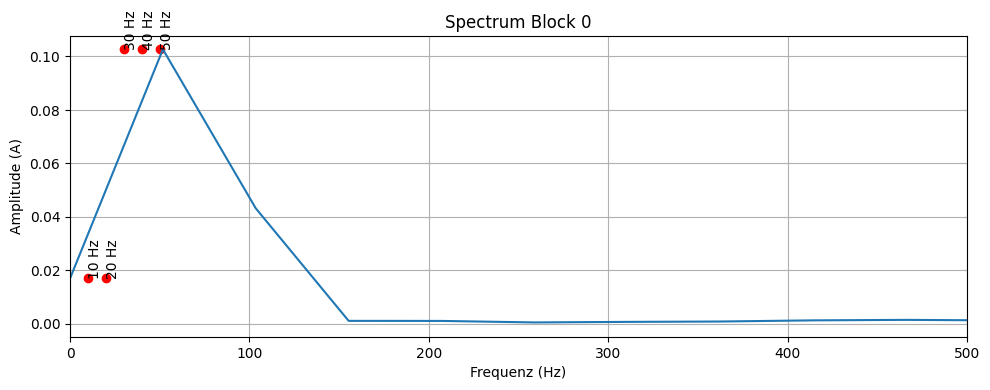

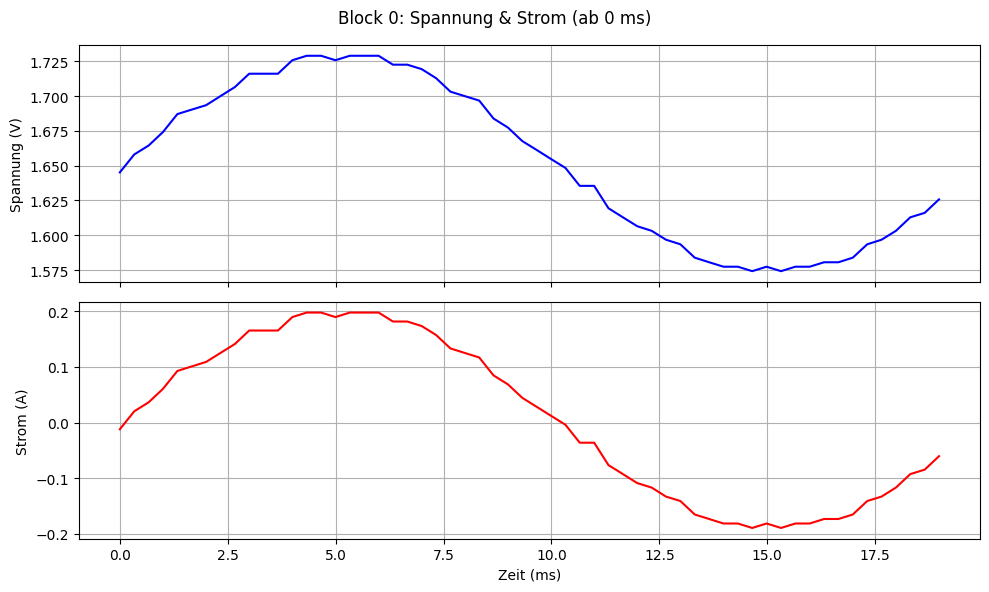


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.139923 A
I_max:                    0.197600 A
P ≈ I_rms * 220 V:        30.783 W

Feature-Vektor:
[0.1399226861643539, 0.1976, 0.016873893997766617, 0.016873893997766617, 0.10258311136120997, 0.10258311136120997, 0.10258311136120997]

        BLOCK 1
----- Abtastraten-Analyse -----
Anzahl Punkte:            240
Mittlerer Abstand:        332.99 µs
Reale Abtastrate:         3003.08 Hz
Blockdauer:               0.0796 s

----- Spektrale Merkmale -----
Amplitude   10 Hz:     0.001102
Amplitude   20 Hz:     0.000976
Amplitude   30 Hz:     0.000976
Amplitude   40 Hz:     0.045614
Amplitude   50 Hz:     0.104667


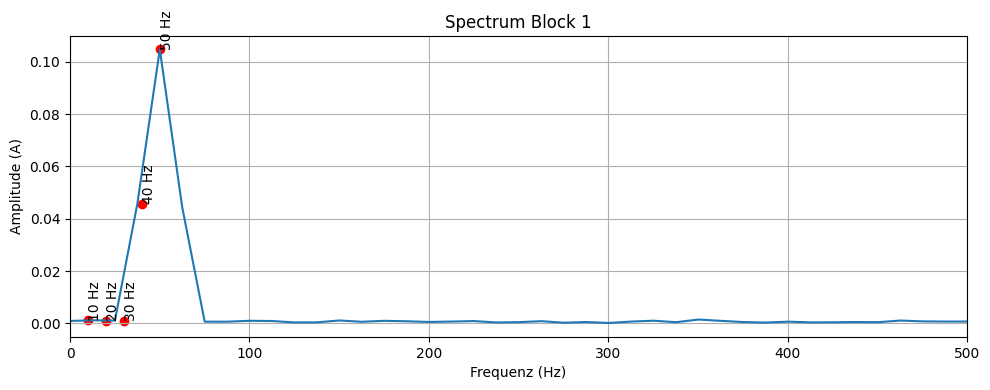

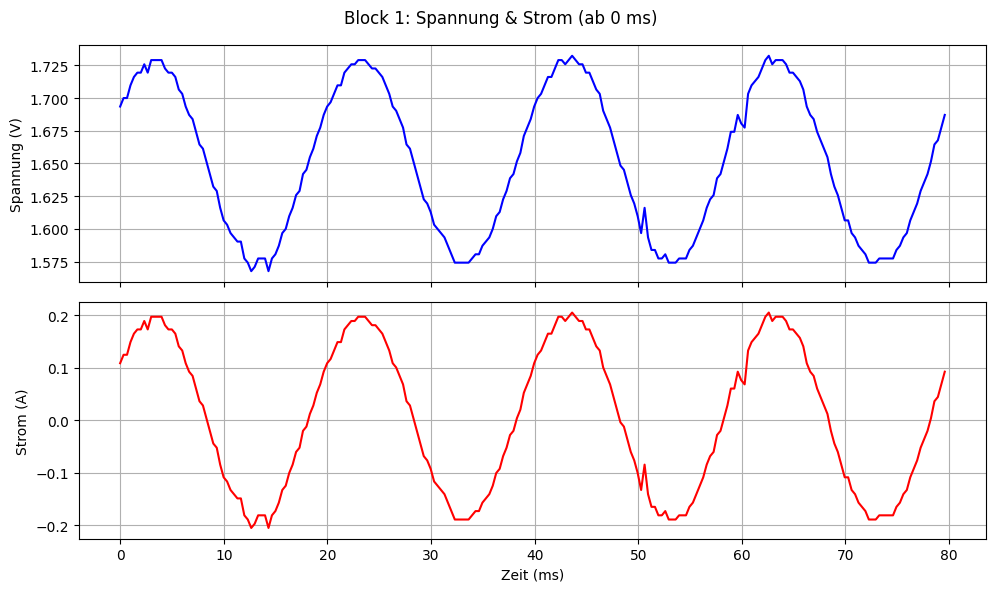


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.137815 A
I_max:                    0.205600 A
P ≈ I_rms * 220 V:        30.319 W

Feature-Vektor:
[0.13781513342155136, 0.2056, 0.00110209026255495, 0.0009763796596372377, 0.0009763796596372377, 0.04561446697363059, 0.10466728468989525]

        BLOCK 2
----- Abtastraten-Analyse -----
Anzahl Punkte:            240
Mittlerer Abstand:        333.00 µs
Reale Abtastrate:         3003.04 Hz
Blockdauer:               0.0796 s

----- Spektrale Merkmale -----
Amplitude   10 Hz:     0.001161
Amplitude   20 Hz:     0.000389
Amplitude   30 Hz:     0.000389
Amplitude   40 Hz:     0.043819
Amplitude   50 Hz:     0.103500


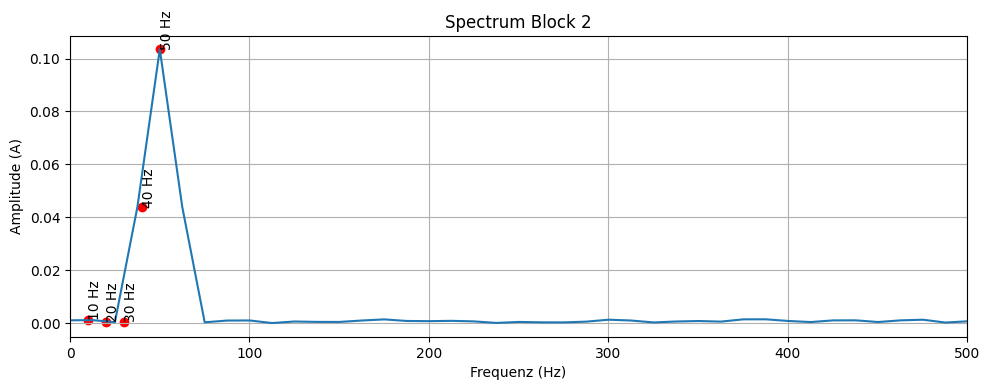

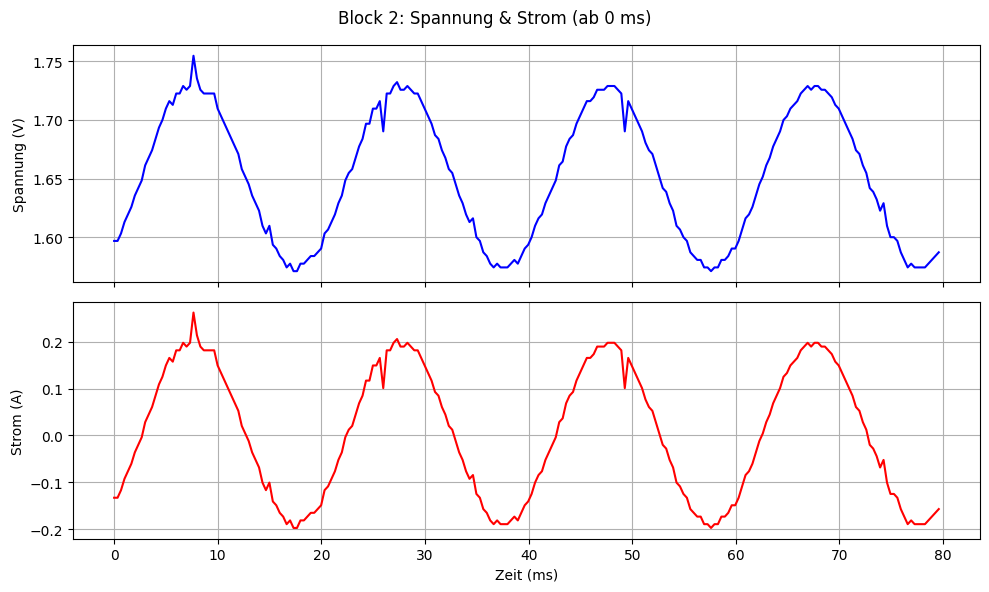


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.137300 A
I_max:                    0.262100 A
P ≈ I_rms * 220 V:        30.206 W

Feature-Vektor:
[0.137299656317851, 0.2621, 0.0011607950367518917, 0.0003888753269658856, 0.0003888753269658856, 0.043819067629644354, 0.1034997311275954]

        BLOCK 3
----- Abtastraten-Analyse -----
Anzahl Punkte:            240
Mittlerer Abstand:        332.99 µs
Reale Abtastrate:         3003.08 Hz
Blockdauer:               0.0796 s

----- Spektrale Merkmale -----
Amplitude   10 Hz:     0.000691
Amplitude   20 Hz:     0.000124
Amplitude   30 Hz:     0.000124
Amplitude   40 Hz:     0.043861
Amplitude   50 Hz:     0.102821


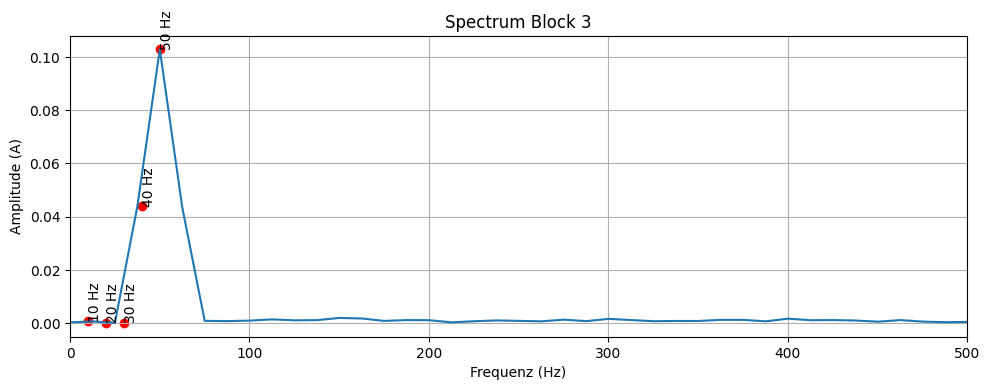

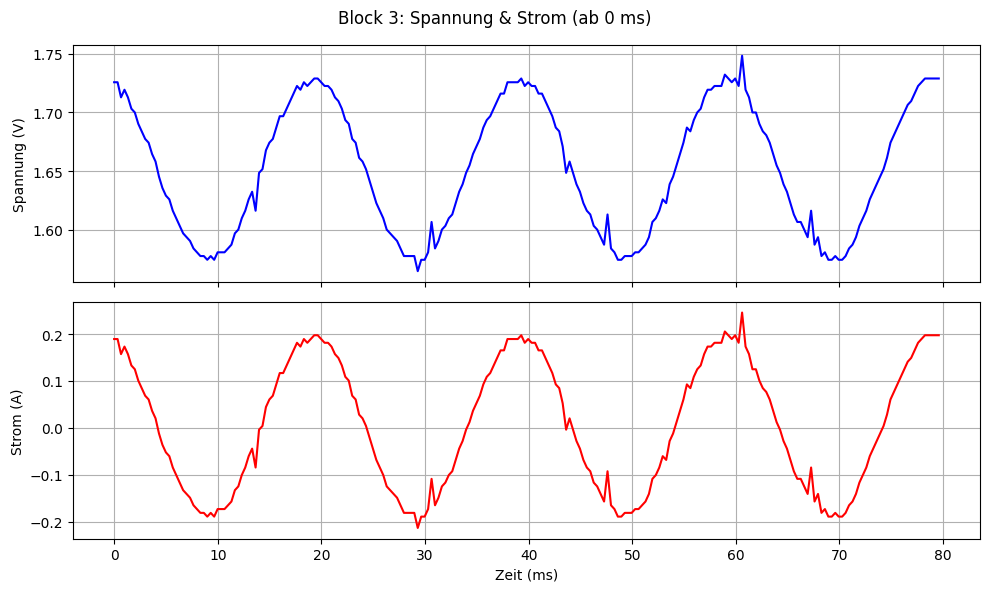


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.136102 A
I_max:                    0.246000 A
P ≈ I_rms * 220 V:        29.942 W

Feature-Vektor:
[0.13610159486574727, 0.246, 0.0006907667748689166, 0.00012373996926426178, 0.00012373996926426178, 0.04386125976402386, 0.10282130652839475]

        BLOCK 4
----- Abtastraten-Analyse -----
Anzahl Punkte:            213
Mittlerer Abstand:        333.00 µs
Reale Abtastrate:         3003.05 Hz
Blockdauer:               0.0706 s

----- Spektrale Merkmale -----
Amplitude   10 Hz:     0.003600
Amplitude   20 Hz:     0.003600
Amplitude   30 Hz:     0.010060
Amplitude   40 Hz:     0.080199
Amplitude   50 Hz:     0.087797


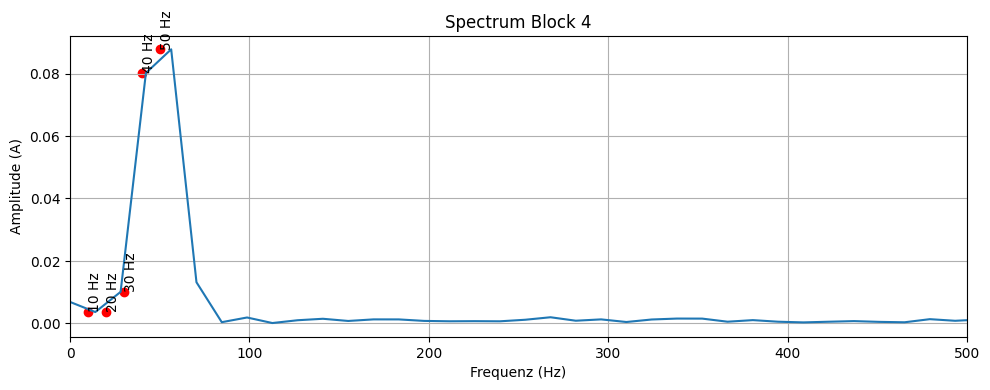

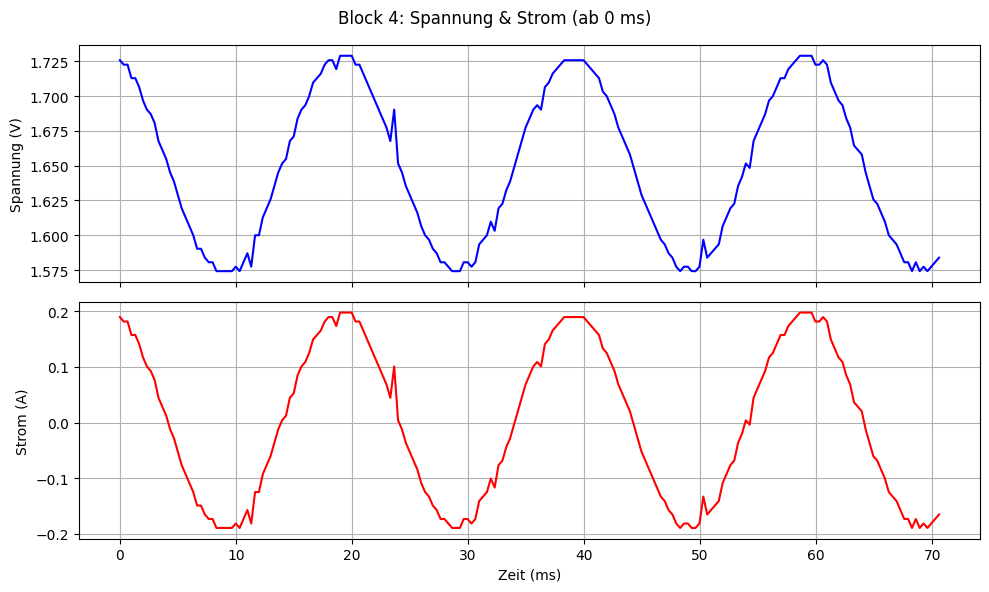


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.136972 A
I_max:                    0.197600 A
P ≈ I_rms * 220 V:        30.134 W

Feature-Vektor:
[0.13697201163679748, 0.1976, 0.003599718753194786, 0.003599718753194786, 0.01005955264620929, 0.08019892423746142, 0.08779689086995257]


===== Alle Feature-Vektoren =====
Block 0: [0.1399226861643539, 0.1976, 0.016873893997766617, 0.016873893997766617, 0.10258311136120997, 0.10258311136120997, 0.10258311136120997]
Block 1: [0.13781513342155136, 0.2056, 0.00110209026255495, 0.0009763796596372377, 0.0009763796596372377, 0.04561446697363059, 0.10466728468989525]
Block 2: [0.137299656317851, 0.2621, 0.0011607950367518917, 0.0003888753269658856, 0.0003888753269658856, 0.043819067629644354, 0.1034997311275954]
Block 3: [0.13610159486574727, 0.246, 0.0006907667748689166, 0.00012373996926426178, 0.00012373996926426178, 0.04386125976402386, 0.10282130652839475]
Block 4: [0.13697201163679748, 0.1976, 0.003599718753194786, 0.003599718753

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1️⃣ Datei einlesen ===
filename = "dataVint_stuf3.txt"

df = pd.read_csv(
    filename,
    sep=r"\s+",
    header=None,
    names=["time_us", "voltage_V", "current_A"]
)

# Zeit in Sekunden
df["time_s"] = df["time_us"] * 1e-6

# === 2️⃣ Zeit-Sprünge erkennen (mehrere Messblöcke!) ===
dt = df["time_us"].diff()
threshold = 2 * dt.median()              # robust
df["block"] = (dt > threshold).cumsum()

n_blocks = df["block"].max() + 1
print(f"\nGefundene Messblöcke: {n_blocks}\n")

# Für Ergebnisse
all_features = []

# =====================================
# === 3️⃣ Verarbeitung JE BLOCK ========
# =====================================
for blk, d in df.groupby("block"):
    print(f"\n===============================")
    print(f"        BLOCK {blk}")
    print(f"===============================")

    # Zeit normieren (Start bei 0)
    time_s = d["time_s"].to_numpy()
    time_s = time_s - time_s[0]

    # reale Abtastrate
    dt_s = np.diff(time_s)
    mean_dt_s = dt_s.mean()
    fs_real = 1.0 / mean_dt_s

    print("----- Abtastraten-Analyse -----")
    print(f"Anzahl Punkte:            {len(d)}")
    print(f"Mittlerer Abstand:        {mean_dt_s*1e6:.2f} µs")
    print(f"Reale Abtastrate:         {fs_real:.2f} Hz")
    print(f"Blockdauer:               {time_s[-1]:.4f} s")

    # === Stromsignal ===
    I = d["current_A"].to_numpy()
    I_ac = I - I.mean()

    # Fenster
    N = len(I_ac)
    window = np.hamming(N)
    I_win = I_ac * window

    # === FFT ===
    freqs = np.fft.rfftfreq(N, d=mean_dt_s)
    I_fft = np.fft.rfft(I_win)
    mag = np.abs(I_fft) * 2.0 / N   # einfache Normierung

    # Frequenzen, die du auswerten willst
    freq_targets = [10,20, 30, 40, 50]
    amps = []

    print("\n----- Spektrale Merkmale -----")
    for f in freq_targets:
        idx = np.argmin(np.abs(freqs - f))
        amps.append(mag[idx])
        print(f"Amplitude {f:4.0f} Hz:     {mag[idx]:.6f}")

    # === Spektrum plotten ===
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, mag, label=f"Block {blk}")
    for f, a in zip(freq_targets, amps):
        plt.scatter(f, a, color="red")
        plt.text(f, a, f"{f} Hz", rotation=90, va="bottom")
    plt.xlim(0, 500)
    plt.grid(True)
    plt.title(f"Spectrum Block {blk}")
    plt.xlabel("Frequenz (Hz)")
    plt.ylabel("Amplitude (A)")
    plt.tight_layout()
    plt.show()

    # === Zeitbereichsplots ===
    time_ms = time_s * 1000

    fig, (axV, axI) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axV.plot(time_ms, d["voltage_V"], color="blue")
    axV.set_ylabel("Spannung (V)")
    axV.grid(True)

    axI.plot(time_ms, d["current_A"], color="red")
    axI.set_ylabel("Strom (A)")
    axI.set_xlabel("Zeit (ms)")
    axI.grid(True)

    plt.suptitle(f"Block {blk}: Spannung & Strom (ab 0 ms)")
    plt.tight_layout()
    plt.show()

    # === RMS/Max/Leistung ===
    I_rms = np.sqrt(np.mean(I**2))
    I_max = np.max(np.abs(I))
    U_nom = 220.0
    P_rms = I_rms * U_nom

    print("\n----- Zeitbereich-Merkmale -----")
    print(f"I_rms (Gesamt):           {I_rms:.6f} A")
    print(f"I_max:                    {I_max:.6f} A")
    print(f"P ≈ I_rms * 220 V:        {P_rms:.3f} W")

    # Feature-Vektor
    feature_vec = [I_rms, I_max] + amps
    all_features.append(feature_vec)

    print("\nFeature-Vektor:")
    print(feature_vec)

# ================================================
# === 4️⃣ Zusammenfassung aller Blöcke ===========
# ================================================

print("\n\n===== Alle Feature-Vektoren =====")
for i, fv in enumerate(all_features):
    print(f"Block {i}: {fv}")



Gefundene Messblöcke: 2


        BLOCK 0
----- Abtastraten-Analyse -----
Anzahl Punkte:            216
Mittlerer Abstand:        333.00 µs
Reale Abtastrate:         3003.00 Hz
Blockdauer:               0.0716 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.143273
Amplitude  100 Hz:     0.000791
Amplitude  150 Hz:     0.152911
Amplitude  200 Hz:     0.005135
Amplitude  250 Hz:     0.145924


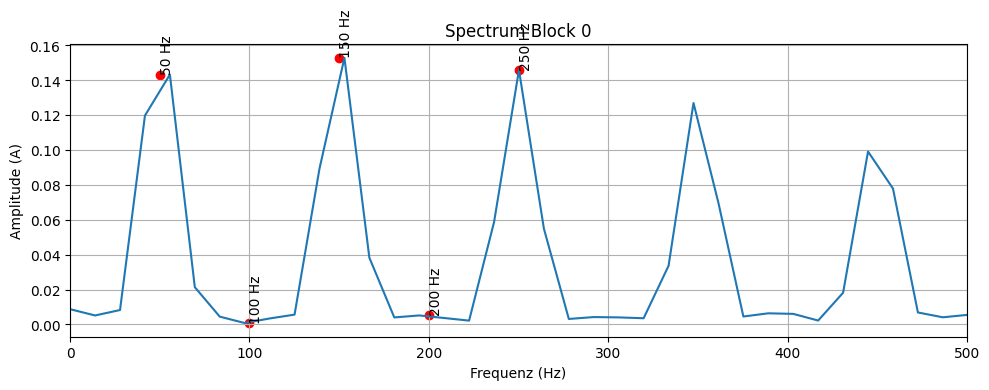

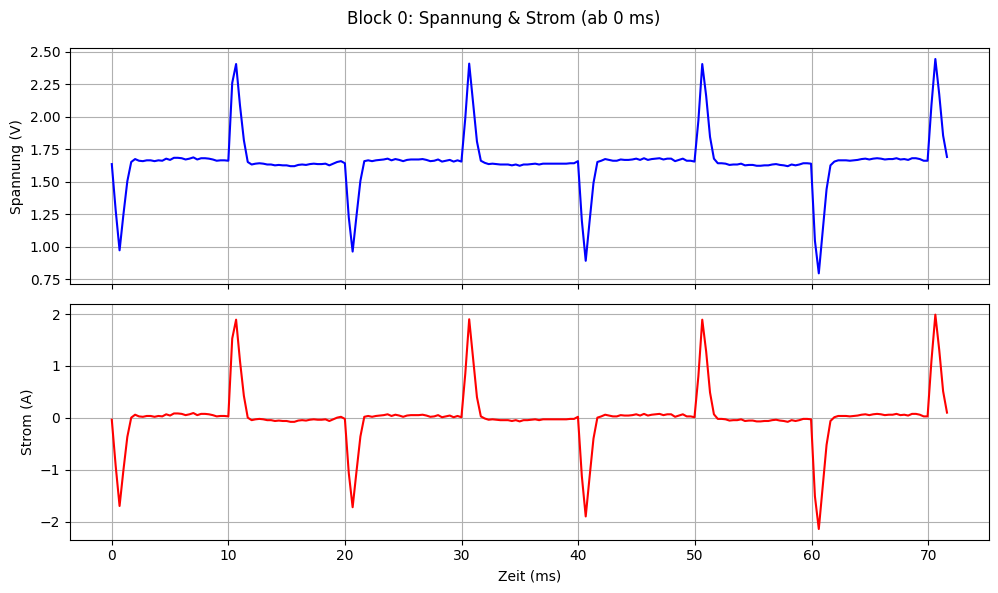


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.491182 A
I_max:                    2.141100 A
P ≈ I_rms * 220 V:        108.060 W

Feature-Vektor:
[0.49118241222923825, 2.1411, 0.14327299811264013, 0.000791254319441903, 0.1529111834744662, 0.005135052562219514, 0.1459243825767781]

        BLOCK 1
----- Abtastraten-Analyse -----
Anzahl Punkte:            159
Mittlerer Abstand:        332.99 µs
Reale Abtastrate:         3003.12 Hz
Blockdauer:               0.0526 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.159686
Amplitude  100 Hz:     0.000510
Amplitude  150 Hz:     0.171377
Amplitude  200 Hz:     0.000958
Amplitude  250 Hz:     0.148406


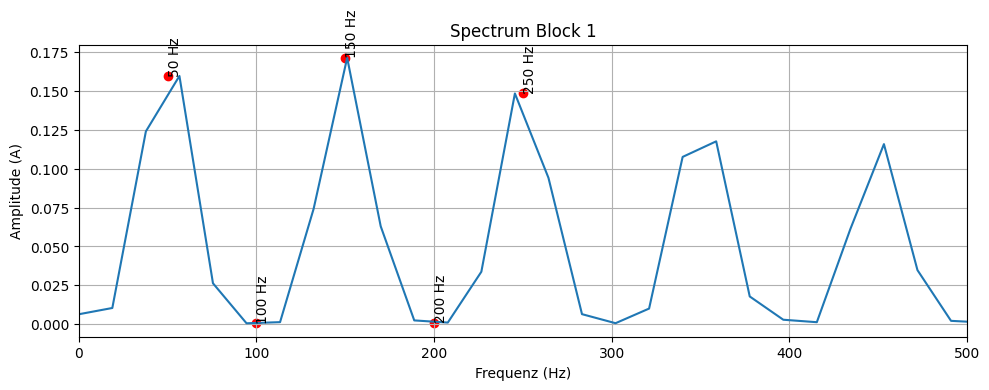

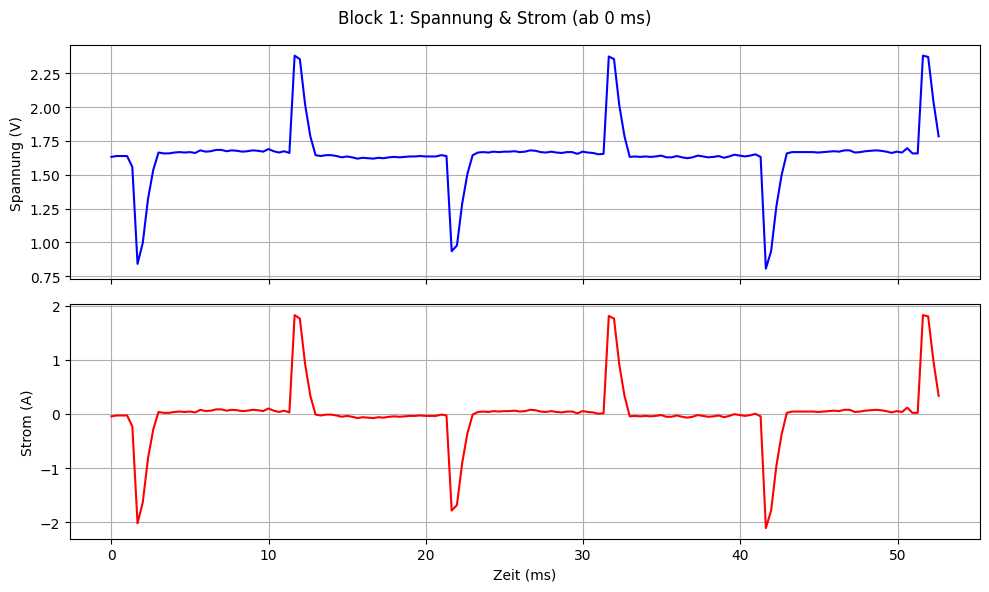


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.537611 A
I_max:                    2.108900 A
P ≈ I_rms * 220 V:        118.274 W

Feature-Vektor:
[0.5376112115459221, 2.1089, 0.15968631614591308, 0.0005103523774733137, 0.1713768557351178, 0.0009576525499703538, 0.14840593849463]


===== Alle Feature-Vektoren =====
Block 0: [0.49118241222923825, 2.1411, 0.14327299811264013, 0.000791254319441903, 0.1529111834744662, 0.005135052562219514, 0.1459243825767781]
Block 1: [0.5376112115459221, 2.1089, 0.15968631614591308, 0.0005103523774733137, 0.1713768557351178, 0.0009576525499703538, 0.14840593849463]


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1️⃣ Datei einlesen ===
filename = "Laptov_netzteil.txt"

df = pd.read_csv(
    filename,
    sep=r"\s+",
    header=None,
    names=["time_us", "voltage_V", "current_A"]
)

# Zeit in Sekunden
df["time_s"] = df["time_us"] * 1e-6

# === 2️⃣ Zeit-Sprünge erkennen (mehrere Messblöcke!) ===
dt = df["time_us"].diff()
threshold = 2 * dt.median()              # robust
df["block"] = (dt > threshold).cumsum()

n_blocks = df["block"].max() + 1
print(f"\nGefundene Messblöcke: {n_blocks}\n")

# Für Ergebnisse
all_features = []

# =====================================
# === 3️⃣ Verarbeitung JE BLOCK ========
# =====================================
for blk, d in df.groupby("block"):
    print(f"\n===============================")
    print(f"        BLOCK {blk}")
    print(f"===============================")

    # Zeit normieren (Start bei 0)
    time_s = d["time_s"].to_numpy()
    time_s = time_s - time_s[0]

    # reale Abtastrate
    dt_s = np.diff(time_s)
    mean_dt_s = dt_s.mean()
    fs_real = 1.0 / mean_dt_s

    print("----- Abtastraten-Analyse -----")
    print(f"Anzahl Punkte:            {len(d)}")
    print(f"Mittlerer Abstand:        {mean_dt_s*1e6:.2f} µs")
    print(f"Reale Abtastrate:         {fs_real:.2f} Hz")
    print(f"Blockdauer:               {time_s[-1]:.4f} s")

    # === Stromsignal ===
    I = d["current_A"].to_numpy()
    I_ac = I - I.mean()

    # Fenster
    N = len(I_ac)
    window = np.hamming(N)
    I_win = I_ac * window

    # === FFT ===
    freqs = np.fft.rfftfreq(N, d=mean_dt_s)
    I_fft = np.fft.rfft(I_win)
    mag = np.abs(I_fft) * 2.0 / N   # einfache Normierung

    # Frequenzen, die du auswerten willst
    freq_targets = [50,100, 150, 200, 250]
    amps = []

    print("\n----- Spektrale Merkmale -----")
    for f in freq_targets:
        idx = np.argmin(np.abs(freqs - f))
        amps.append(mag[idx])
        print(f"Amplitude {f:4.0f} Hz:     {mag[idx]:.6f}")

    # === Spektrum plotten ===
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, mag, label=f"Block {blk}")
    for f, a in zip(freq_targets, amps):
        plt.scatter(f, a, color="red")
        plt.text(f, a, f"{f} Hz", rotation=90, va="bottom")
    plt.xlim(0, 500)
    plt.grid(True)
    plt.title(f"Spectrum Block {blk}")
    plt.xlabel("Frequenz (Hz)")
    plt.ylabel("Amplitude (A)")
    plt.tight_layout()
    plt.show()

    # === Zeitbereichsplots ===
    time_ms = time_s * 1000

    fig, (axV, axI) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axV.plot(time_ms, d["voltage_V"], color="blue")
    axV.set_ylabel("Spannung (V)")
    axV.grid(True)

    axI.plot(time_ms, d["current_A"], color="red")
    axI.set_ylabel("Strom (A)")
    axI.set_xlabel("Zeit (ms)")
    axI.grid(True)

    plt.suptitle(f"Block {blk}: Spannung & Strom (ab 0 ms)")
    plt.tight_layout()
    plt.show()

    # === RMS/Max/Leistung ===
    I_rms = np.sqrt(np.mean(I**2))
    I_max = np.max(np.abs(I))
    U_nom = 220.0
    P_rms = I_rms * U_nom

    print("\n----- Zeitbereich-Merkmale -----")
    print(f"I_rms (Gesamt):           {I_rms:.6f} A")
    print(f"I_max:                    {I_max:.6f} A")
    print(f"P ≈ I_rms * 220 V:        {P_rms:.3f} W")

    # Feature-Vektor
    feature_vec = [I_rms, I_max] + amps
    all_features.append(feature_vec)

    print("\nFeature-Vektor:")
    print(feature_vec)

# ================================================
# === 4️⃣ Zusammenfassung aller Blöcke ===========
# ================================================

print("\n\n===== Alle Feature-Vektoren =====")
for i, fv in enumerate(all_features):
    print(f"Block {i}: {fv}")
